# Similar Companies & Industry Benchmarking

Given a target company, find similar ones and benchmark its metrics
against industry peers. Requires VynCo API v3.1+ (`/companies/{uid}/similar`
and `/analytics/benchmark`).

```bash
pip install vynco matplotlib seaborn
```

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import vynco

sns.set_theme(style="whitegrid", font_scale=1.1)
ACCENT = "#2e86ab"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

client = vynco.Client()

# --- Find target company ---
search = client.companies.list(query="ABB", canton="ZH", page_size=1)
TARGET_UID = search.data.items[0].uid
print(f"Target: {search.data.items[0].name} ({TARGET_UID})")

Target: ABB SA (CHE-101.049.653)


## 1. Similar Companies

Find companies scored by similarity on industry (40pts), canton (20pts),
capital proximity (20pts), legal form (10pts), and auditor tier (10pts).

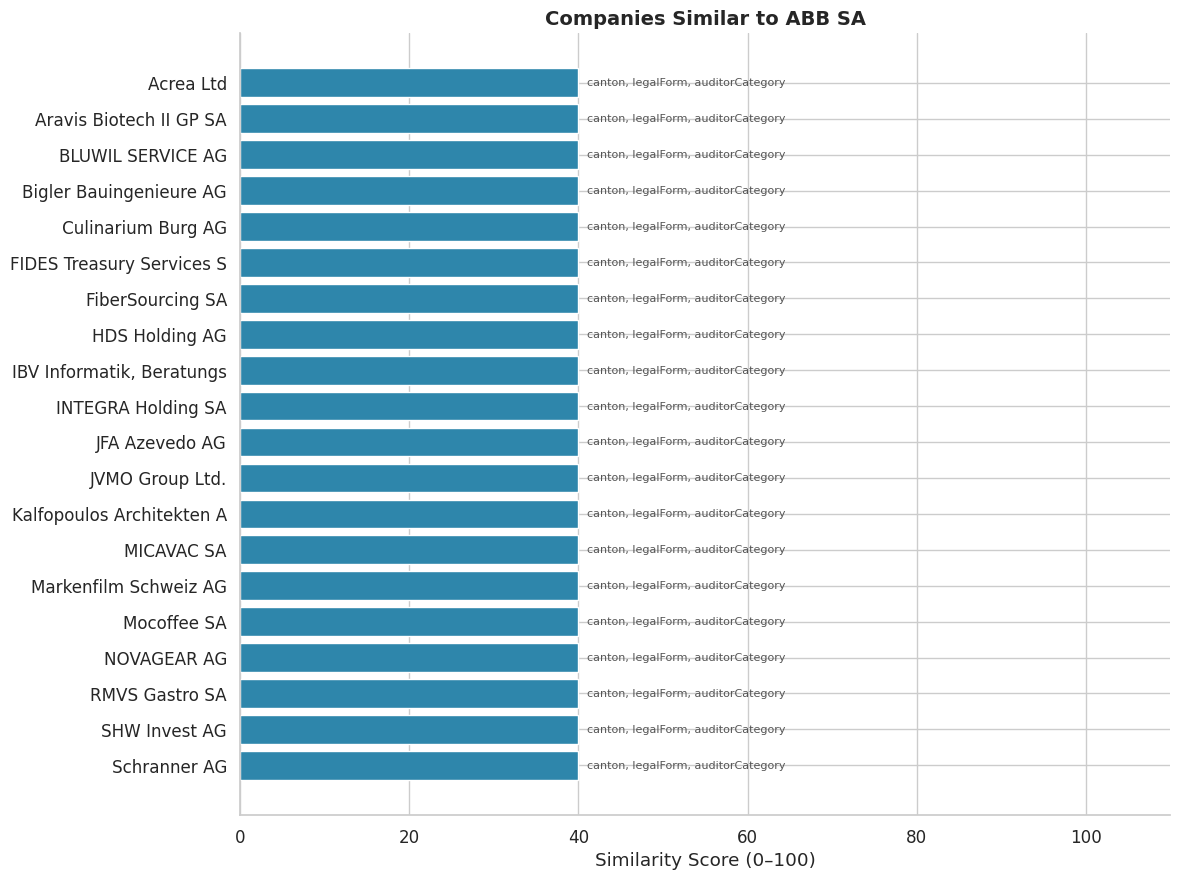


Top 5 matches:
   40/100  Acrea Ltd                                 ZH    None
   40/100  Aravis Biotech II GP SA                   ZH    None
   40/100  BLUWIL SERVICE AG                         ZH    None
   40/100  Bigler Bauingenieure AG                   ZH    None
   40/100  Culinarium Burg AG                        ZH    None


In [2]:
similar = client.companies.similar(TARGET_UID, limit=20).data

names = [r.name[:25] for r in similar.results]
scores = [r.similarity_score for r in similar.results]
colors = ["#1e3a5f" if s >= 70 else "#2e86ab" if s >= 40 else "#999" for s in scores]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(names[::-1], scores[::-1], color=colors[::-1], edgecolor="white")

# Show matching dimensions as labels
for i, r in enumerate(reversed(similar.results)):
    dims = ", ".join(r.matching_dimensions[:3])
    ax.text(r.similarity_score + 1, i, dims, va="center", fontsize=8, color="#555")

ax.set_xlim(0, 110)
ax.set_xlabel("Similarity Score (0–100)")
ax.set_title(f"Companies Similar to {similar.company_name}",
             fontsize=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/similar_companies.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 5 matches:")
for r in similar.results[:5]:
    print(f"  {r.similarity_score:>3}/100  {r.name:<40}  {r.canton:<4}  {r.industry}")

## 2. Industry Benchmark — Radar Chart

Position this company against its industry peers on a radar chart
using percentile ranks.

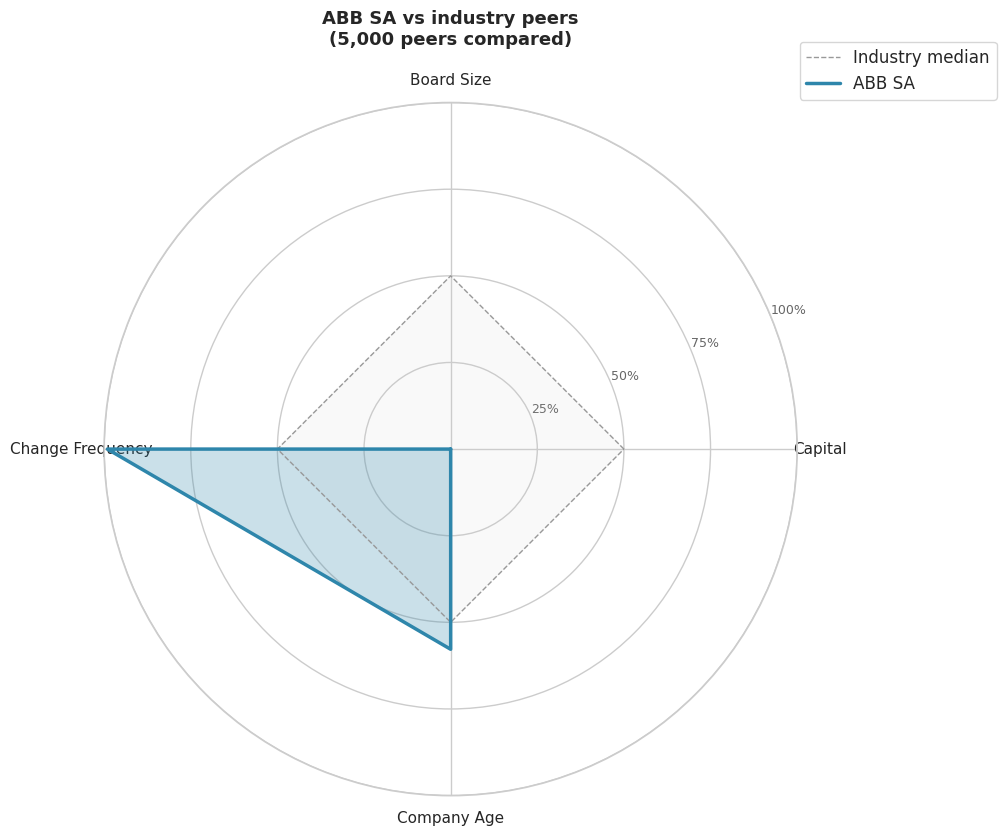

In [3]:
bench = client.analytics.benchmark(uid=TARGET_UID).data

dims = bench.dimensions
labels = [d.name.replace("_", " ").title() for d in dims]
percentiles = [d.percentile for d in dims]

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
percentiles += percentiles[:1]
angles += angles[:1]
median = [50] * len(labels)
median += median[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})

# Median reference (50th percentile)
ax.plot(angles, median, color="#999", linewidth=1, linestyle="--", label="Industry median")
ax.fill(angles, median, color="#ccc", alpha=0.1)

# Company values
ax.plot(angles, percentiles, color=ACCENT, linewidth=2.5, label=bench.company_name)
ax.fill(angles, percentiles, color=ACCENT, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=9, color="#666")
ax.set_title(f"{bench.company_name} vs {bench.industry or 'industry'} peers\n"
             f"({bench.peer_count:,} peers compared)",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.savefig(f"{FIG_DIR}/benchmark_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Benchmark Detail Table

Raw values alongside industry medians and percentile ranks.

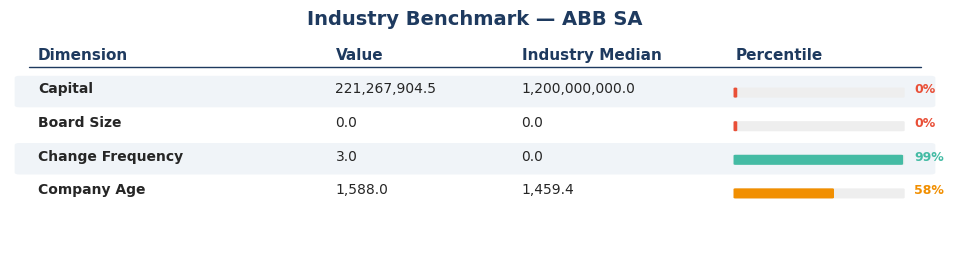

In [4]:
fig, ax = plt.subplots(figsize=(12, max(3, len(dims) * 0.5 + 1)))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(dims) + 1.5)
ax.axis("off")

# Header
header_y = len(dims) + 1
cols = [(0.3, "Dimension"), (3.5, "Value"), (5.5, "Industry Median"),
        (7.8, "Percentile")]
for x, label in cols:
    ax.text(x, header_y, label, fontsize=11, fontweight="bold", color="#1e3a5f")
ax.plot([0.2, 9.8], [header_y - 0.2, header_y - 0.2], color="#1e3a5f", linewidth=1)

for i, d in enumerate(dims):
    y = header_y - 0.8 - i * 0.8
    if i % 2 == 0:
        rect = mpatches.FancyBboxPatch((0.1, y - 0.3), 9.8, 0.65,
                                        boxstyle="round,pad=0.05",
                                        facecolor="#f0f4f8", edgecolor="none")
        ax.add_patch(rect)

    ax.text(0.3, y, d.name.replace("_", " ").title(), fontsize=10,
            fontweight="bold")
    ax.text(3.5, y, f"{d.company_value:,.1f}", fontsize=10)
    ax.text(5.5, y, f"{d.industry_median:,.1f}", fontsize=10)

    # Percentile bar
    pct_color = ("#44bba4" if d.percentile >= 75
                 else "#f18f01" if d.percentile >= 40
                 else "#e94f37")
    bar_bg = mpatches.FancyBboxPatch((7.8, y - 0.1), 1.8, 0.2,
                                      boxstyle="round,pad=0.02",
                                      facecolor="#eee", edgecolor="none")
    ax.add_patch(bar_bg)
    bar_fg = mpatches.FancyBboxPatch((7.8, y - 0.1), 1.8 * d.percentile / 100, 0.2,
                                      boxstyle="round,pad=0.02",
                                      facecolor=pct_color, edgecolor="none")
    ax.add_patch(bar_fg)
    ax.text(9.72, y, f"{d.percentile:.0f}%", fontsize=9,
            fontweight="bold", color=pct_color)

ax.set_title(f"Industry Benchmark — {bench.company_name}",
             fontsize=14, fontweight="bold", color="#1e3a5f", pad=10)
plt.savefig(f"{FIG_DIR}/benchmark_table.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()